<a href="https://colab.research.google.com/github/Sj-kronton/IA_2025/blob/main/arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AGENDA

1. Se haran cosas con un data set
2. exploracion de datos EDA
3. Limpieza de datos
4. Entrenar el modelo (arbol de decision)
5. Evaluar el modelo

In [476]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split #partir el dataset
from sklearn.tree import DecisionTreeRegressor #modelo de arbol
from sklearn.tree import plot_tree #dibujar arbol
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score

#OBJETIVO

crear y evaluar un modelo de arbol de decision para predecir las ventas con datos simulados de una empresa, dependiendo de las inversiones realizadas en publicidad

In [477]:
datos=pd.read_csv('https://raw.githubusercontent.com/rpizarrog/Analisis-Inteligente-de-datos/main/datos/Advertising_Web.csv')
datos.head()

,Unnamed: 0,X,TV,Radio,Newspaper,Web,Sales
0,1,1,230.1,37.8,69.2,306.634752,22.1
1,2,2,44.5,39.3,45.1,302.653070,10.4
2,3,3,17.2,45.9,69.3,49.498908,9.3
3,4,4,151.5,41.3,58.5,257.816893,18.5
4,5,5,180.8,10.8,58.4,195.660076,12.9


In [478]:
df=pd.DataFrame(datos) #crear datafrme y buscar las variables dpeendientes e independientes
df.head()

,Unnamed: 0,X,TV,Radio,Newspaper,Web,Sales
0,1,1,230.1,37.8,69.2,306.634752,22.1
1,2,2,44.5,39.3,45.1,302.653070,10.4
2,3,3,17.2,45.9,69.3,49.498908,9.3
3,4,4,151.5,41.3,58.5,257.816893,18.5
4,5,5,180.8,10.8,58.4,195.660076,12.9


/tmp/ipython-input-2657983762.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


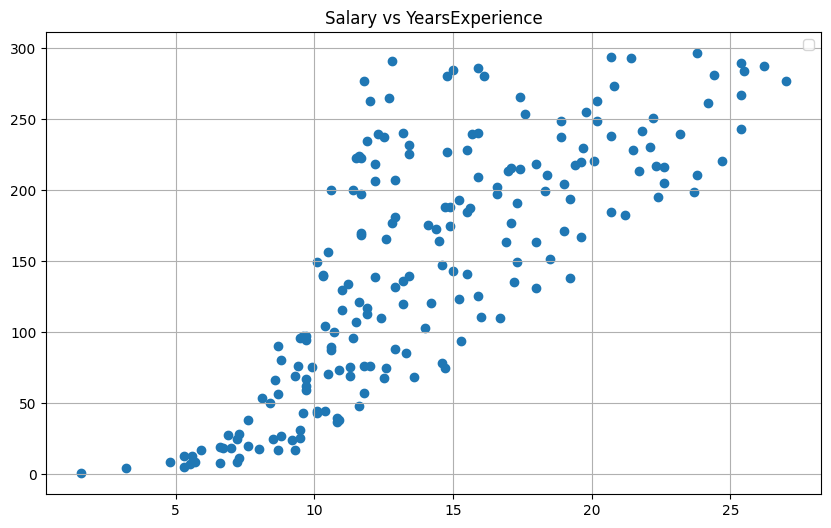

In [479]:
x=df["Sales"] #variables dependientes e independientes
y=df["TV"]#esta es la dependiente

plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.title("Salary vs YearsExperience")
plt.legend()
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'TV vs Sales')

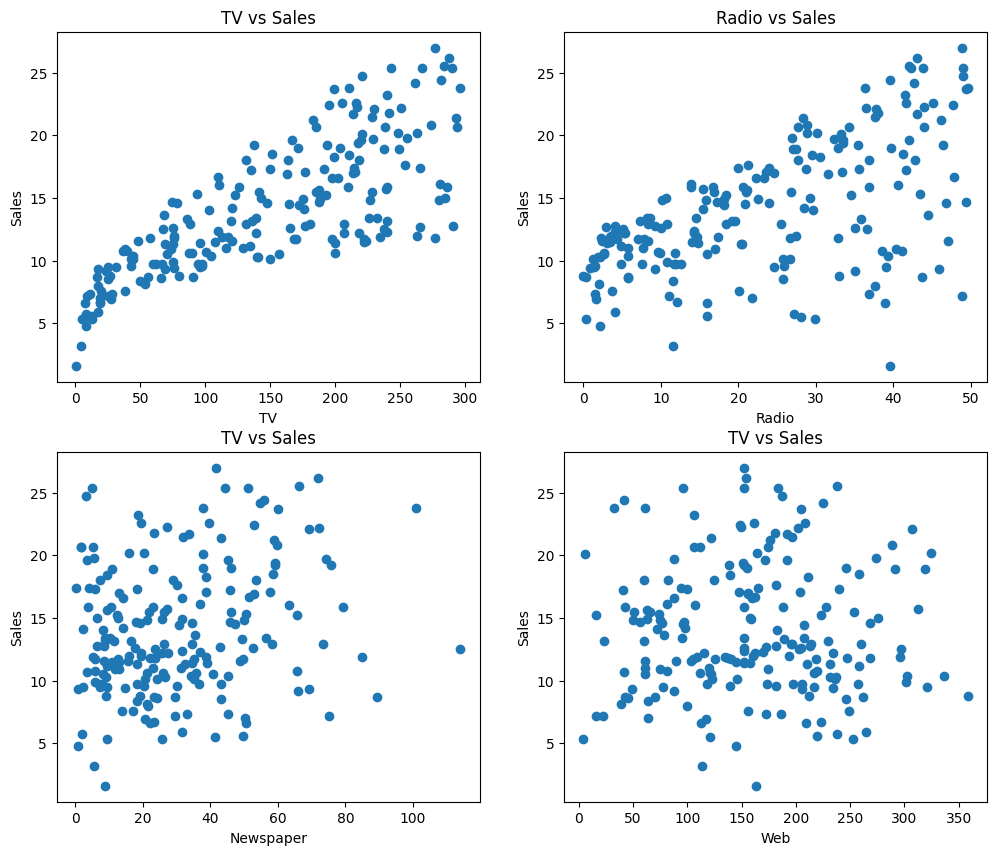

In [480]:
fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(12,10))

axes[0,0].scatter(df["TV"],df["Sales"])
axes[0,0].set_xlabel("TV")
axes[0,0].set_ylabel("Sales")
axes[0,0].set_title("TV vs Sales")

axes[0,1].scatter(df["Radio"],df["Sales"])
axes[0,1].set_xlabel("Radio")
axes[0,1].set_ylabel("Sales")
axes[0,1].set_title("Radio vs Sales")

axes[1,0].scatter(df["Newspaper"],df["Sales"])
axes[1,0].set_xlabel("Newspaper")
axes[1,0].set_ylabel("Sales")
axes[1,0].set_title("TV vs Sales")

axes[1,1].scatter(df["Web"],df["Sales"])
axes[1,1].set_xlabel("Web")
axes[1,1].set_ylabel("Sales")
axes[1,1].set_title("TV vs Sales")

##Exploracion de datos EDA

In [481]:
print("Observaciones y variables: ", datos.shape)

Observaciones y variables:  (200, 7)


In [482]:
datos.dtypes

,0
Unnamed: 0,int64
X,int64
TV,float64
Radio,float64
Newspaper,float64
Web,float64
Sales,float64


In [483]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   X           200 non-null    int64  
 2   TV          200 non-null    float64
 3   Radio       200 non-null    float64
 4   Newspaper   200 non-null    float64
 5   Web         200 non-null    float64
 6   Sales       200 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 11.1 KB


Se describen las variables como variables independientes TV, Radio, Newspaper Y Web
y como variable dependiente Sales.

Independientes:
* Tv: costos de publicidad en TV (miles de dolares)
* Radio: costos de publicidad inestidos en medios de difusion radio (miles de dolares)
* Newspaper: costos publicitarios para medios impresos (miles de dolares)
* Web: costos publicitarios en eherramientas digitales (miles de dolares)

In [484]:
datos.head()

,Unnamed: 0,X,TV,Radio,Newspaper,Web,Sales
0,1,1,230.1,37.8,69.2,306.634752,22.1
1,2,2,44.5,39.3,45.1,302.653070,10.4
2,3,3,17.2,45.9,69.3,49.498908,9.3
3,4,4,151.5,41.3,58.5,257.816893,18.5
4,5,5,180.8,10.8,58.4,195.660076,12.9


##Limpieza de datos

In [485]:
#eliminar columnas inecesarias
datos=datos[["TV", "Radio", "Newspaper", "Web", "Sales"]] #limpiar columnas creando un nuevo dataset con solo los datos necesarios
datos.describe() #calculos basicos de porcentaje

,TV,Radio,Newspaper,Web,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,159.587355,14.022500
std,85.854236,14.846809,21.778621,76.815266,5.217457
min,0.700000,0.000000,0.300000,4.308085,1.600000
25%,74.375000,9.975000,12.750000,99.048767,10.375000
50%,149.750000,22.900000,25.750000,156.862154,12.900000
75%,218.825000,36.525000,45.100000,212.311848,17.400000
max,296.400000,49.600000,114.000000,358.247042,27.000000


##Datos de entrenamiento y datos de validacion (Entrenamiento de modelo)

Se usara la semilla 1279 (random_state=2022)
Los datos se distribuiran de la siguiente maneral:
* 70% para entrenamiento
* 30% para validacion del modelo

In [486]:
X_entrena, X_valida, Y_entrena, Y_valida = train_test_split(datos.drop(columns="Sales"), datos["Sales"],train_size=.7) #,random_state=1279

In [487]:
X_entrena.shape #estructura de datos de entrenamiento

(140, 4)

##Modelando el arbol de decision

La clase DecisionTreeRegressor del modulo sklearn.tree tiene los siguientes parametros:
* max_depth: profundidad maxima que puede alcanzar el arbol.
* min_samples_split: numero minimo de observaciones que debe de tener el nodo para que pueda dividirse, si es decimal se interpreta como la fraccion total de observaciones de entrenamiento (min_samples_split*n_samples)
* min_samples_leaf: numero minimo de observaciones que debe de tener cada uno de los nodos hijos para que se produzca la division
* max_leaf_nodes: numero maximo de nodos terminales
* random_seed: semilla que permite resultados reproducibles
**Es un valor entero**

In [488]:
modelo_ar=DecisionTreeRegressor(max_depth=3) #el random state corresponde a la semilla ,random_state=2022 NOTA: SIEMPRE ADJUNTAR QUE SEMILLA SE USA AL MOMENTO DE HACER REPORTE O UNA TAREA

usamos los datos del entrenamiento con el modelo del arbol de regresion

In [489]:
modelo_ar.fit(X_entrena, Y_entrena)

DecisionTreeRegressor(max_depth=3)

##Visualizacion del modelo


In [490]:
print("Profundidad del arbol: ", modelo_ar.get_depth())
print("Numero de nodos terminales: ", modelo_ar.get_n_leaves())

Profundidad del arbol:  3
Numero de nodos terminales:  8


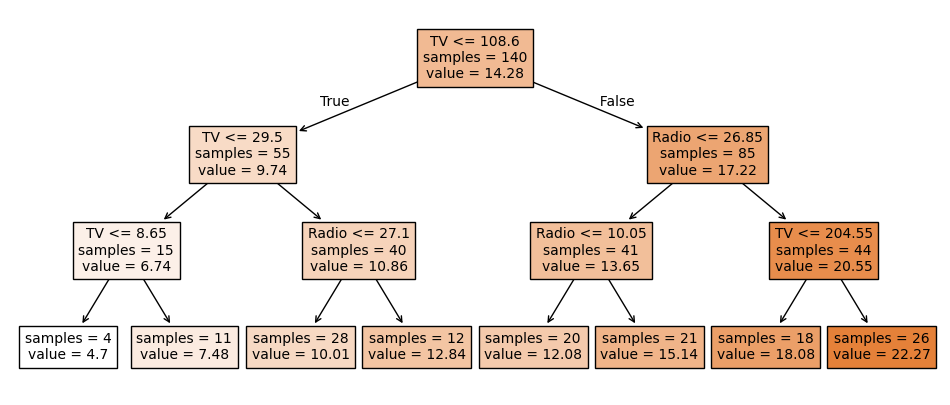

In [491]:
fig,ax=plt.subplots(figsize=(12,5))
plot=plot_tree(
    decision_tree=modelo_ar,
    feature_names=datos.drop(columns="Sales").columns,
    filled=True,
    impurity=False,
    fontsize=10,
    precision=2,
    ax=ax
)

In [492]:
texto_modelo=export_text(
    decision_tree=modelo_ar,
    feature_names=datos.drop(columns="Sales").columns
) #el arbol pero en texto en lugar de en un modelo
print(texto_modelo)

|--- TV <= 108.60
|   |--- TV <= 29.50
|   |   |--- TV <= 8.65
|   |   |   |--- value: [4.70]
|   |   |--- TV >  8.65
|   |   |   |--- value: [7.48]
|   |--- TV >  29.50
|   |   |--- Radio <= 27.10
|   |   |   |--- value: [10.01]
|   |   |--- Radio >  27.10
|   |   |   |--- value: [12.84]
|--- TV >  108.60
|   |--- Radio <= 26.85
|   |   |--- Radio <= 10.05
|   |   |   |--- value: [12.08]
|   |   |--- Radio >  10.05
|   |   |   |--- value: [15.14]
|   |--- Radio >  26.85
|   |   |--- TV <= 204.55
|   |   |   |--- value: [18.08]
|   |   |--- TV >  204.55
|   |   |   |--- value: [22.27]



##Evaluar la importancia de las predicciones

la importancia de cada predictor en el modelo se calcula como la reduccion total normalizada en el criterio de division. En este caso, el mse que consigue el predictor en las divisiones en las que participa. Si un predictor no se ha seleccionado en ninguna division, no se inlcuye en el modelo y su importancia es de 0

In [493]:
importancia_predictores=pd.DataFrame(
    {
        "predictor":datos.drop(columns="Sales").columns,
        "importancia":modelo_ar.feature_importances_
    }

)

In [494]:
importancia_predictores.sort_values(by="importancia", ascending=False)

,predictor,importancia
0,TV,0.658231
1,Radio,0.341769
2,Newspaper,0.000000
3,Web,0.000000


EJERCICIO DE FLORES


In [495]:
from sklearn.datasets import load_iris
from sklearn import tree
iris = load_iris()
from graphviz import Source
from IPython.display import Image, display

In [496]:
display(Image(url="https://preview.redd.it/under-the-hood-iris-flower-tutorial-beginners-v0-usca0th10q9d1.png?width=640&crop=smart&auto=webp&s=05f650bb0765909c51fa45061a1d2bb962181e7b"))

* Clase 0: categoriza setosa y son los registros del 0 al 49
* Clase 1: Se refiere a Versicolor, que son los registros del 50 al 99
* Clase 2: Se refiere a Virginica y son los registros del 100 al 149

In [497]:
print("Features name = ", iris.feature_names)
print(iris.target)
print("Flor setosa: ", iris.data[0])
print("Flor versicolor: ", iris.data[50])
print("Flor virginica: ", iris.data[100])

Features name =  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Flor setosa:  [5.1 3.5 1.4 0.2]
Flor versicolor:  [7.  3.2 4.7 1.4]
Flor virginica:  [6.3 3.3 6.  2.5]


In [498]:
test_indices=[0,1,50,51,100,101]

train_target=np.delete(iris.target, test_indices) #entrenando con 144 datos
train_data=np.delete(iris.data, test_indices, axis=0)

test_target=iris.target[test_indices]
test_data=iris.data[test_indices]

In [499]:
dtClassifier=tree.DecisionTreeClassifier(random_state=2022) #crear el modelo
dtClassifier.fit(train_data, train_target) #usando el modelo

DecisionTreeClassifier(random_state=2022)

In [500]:
print("\n********Resultados********")
for p in range(len(test_indices)):
  print(f"Test Row {test_indices[p]} pertenece a la clase {test_target[p]}")


********Resultados********
Test Row 0 pertenece a la clase 0
Test Row 1 pertenece a la clase 0
Test Row 50 pertenece a la clase 1
Test Row 51 pertenece a la clase 1
Test Row 100 pertenece a la clase 2
Test Row 101 pertenece a la clase 2


In [501]:
predicted_target=dtClassifier.predict(test_data)

print("\n********Resultados predecidos********")
for p in range(len(test_indices)):
  print(f"Test Row {test_indices[p]} pertenece a la clase {predicted_target[p]}")


********Resultados predecidos********
Test Row 0 pertenece a la clase 0
Test Row 1 pertenece a la clase 0
Test Row 50 pertenece a la clase 1
Test Row 51 pertenece a la clase 1
Test Row 100 pertenece a la clase 2
Test Row 101 pertenece a la clase 2


In [502]:
##graficar arbol

graph = Source(tree.export_graphviz(dtClassifier,out_file=None,
                                    feature_names=iris.feature_names,
                                    class_names=iris.target_names,
                                    filled=True, rounded=True, node_ids=True,
                                    special_characters=True))
graph.format="png"
graph.render("dtree_render",view=True)

'dtree_render.png'

De otra forma

In [503]:
iris2=pd.DataFrame(data=np.c_[iris['data'],iris['target']],
                             columns=iris['feature_names']+["target"])
iris2.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
27,5.2,3.5,1.5,0.2,0.0
95,5.7,3.0,4.2,1.2,1.0
14,5.8,4.0,1.2,0.2,0.0
50,7.0,3.2,4.7,1.4,1.0
123,6.3,2.7,4.9,1.8,2.0
106,4.9,2.5,4.5,1.7,2.0
75,6.6,3.0,4.4,1.4,1.0
36,5.5,3.5,1.3,0.2,0.0
70,5.9,3.2,4.8,1.8,1.0
68,6.2,2.2,4.5,1.5,1.0


In [504]:
print(f"Tamaño del dataframe {iris2.shape}")

Tamaño del dataframe (150, 5)


In [505]:
X_train,  X_test,Y_train, Y_test = train_test_split(iris2.drop(columns="target"),iris2["target"],train_size=.7, random_state=1279 )

In [506]:
modelo_flor=DecisionTreeRegressor(random_state=2022)

In [507]:
modelo_flor.fit(X_train,Y_train)

DecisionTreeRegressor(random_state=2022)

[Text(0.4, 0.9, 'petal width (cm) <= 0.8\nsamples = 105\nvalue = 1.01'),
 Text(0.2, 0.7, 'samples = 35\nvalue = 0.0'),
 Text(0.30000000000000004, 0.8, 'True  '),
 Text(0.6, 0.7, 'petal width (cm) <= 1.75\nsamples = 70\nvalue = 1.51'),
 Text(0.5, 0.8, '  False'),
 Text(0.4, 0.5, 'petal length (cm) <= 4.95\nsamples = 38\nvalue = 1.11'),
 Text(0.2, 0.3, 'samples = 33\nvalue = 1.0'),
 Text(0.6, 0.3, 'petal width (cm) <= 1.65\nsamples = 5\nvalue = 1.8'),
 Text(0.4, 0.1, 'samples = 4\nvalue = 2.0'),
 Text(0.8, 0.1, 'samples = 1\nvalue = 1.0'),
 Text(0.8, 0.5, 'samples = 32\nvalue = 2.0')]

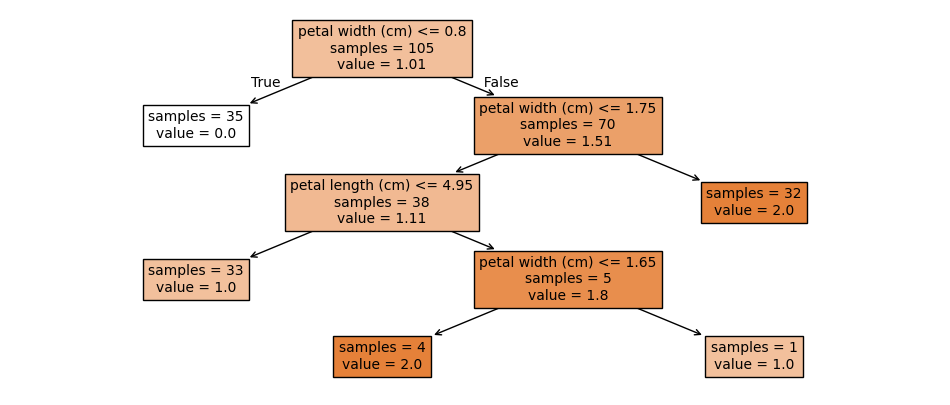

In [508]:
fig, ax=plt.subplots(figsize=(12,5))
plot=plot_tree(
    decision_tree=modelo_flor,
    feature_names=iris2.drop(columns="target").columns,
    filled=True,
    impurity=False,
    fontsize=10,
    precision=2,
    ax=ax)

plot

In [509]:
#importancia de cada dato en el arbol

importancia_predictores3=pd.DataFrame(
    {
        "predictor":iris2.drop(columns="target").columns,
        "importancia":modelo_flor.feature_importances_
    }

)

importancia_predictores3.sort_values(by="importancia", ascending=False)

,predictor,importancia
3,petal width (cm),0.960855
2,petal length (cm),0.039145
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


##tarea de pima indians diabetes database en la pagina de kaggle

In [510]:


import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


In [511]:
pima=pd.read_csv(path+"/diabetes.csv")
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [512]:
pima.shape

(768, 9)

In [513]:
pima.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [514]:
pima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [515]:
pima.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [516]:
#dejar solo columnas utiles
pima=pima[["Glucose", "BloodPressure", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]]
pima.head()

,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148,72,0,33.6,0.627,50
1,85,66,0,26.6,0.351,31
2,183,64,0,23.3,0.672,32
3,89,66,94,28.1,0.167,21
4,137,40,168,43.1,2.288,33


In [517]:
#crear y etrenar el arbol
X_entreno, X_valido, Y_entreno, Y_valido = train_test_split(pima.drop(columns="Glucose"), pima["Glucose"],train_size=.7,random_state=1279) #

In [518]:
X_entreno.shape

(537, 5)

In [519]:
#arbol

modelo_ar2=DecisionTreeRegressor(max_depth=3, random_state=2022) #el random state corresponde a la semilla ,random_state=2022

In [520]:
#entrenamiento del arbol

modelo_ar2.fit(X_entreno, Y_entreno)

DecisionTreeRegressor(max_depth=3, random_state=2022)

In [521]:
print("Profundidad del arbol: ", modelo_ar2.get_depth())
print("Numero de nodos terminales: ", modelo_ar2.get_n_leaves())

Profundidad del arbol:  3
Numero de nodos terminales:  8


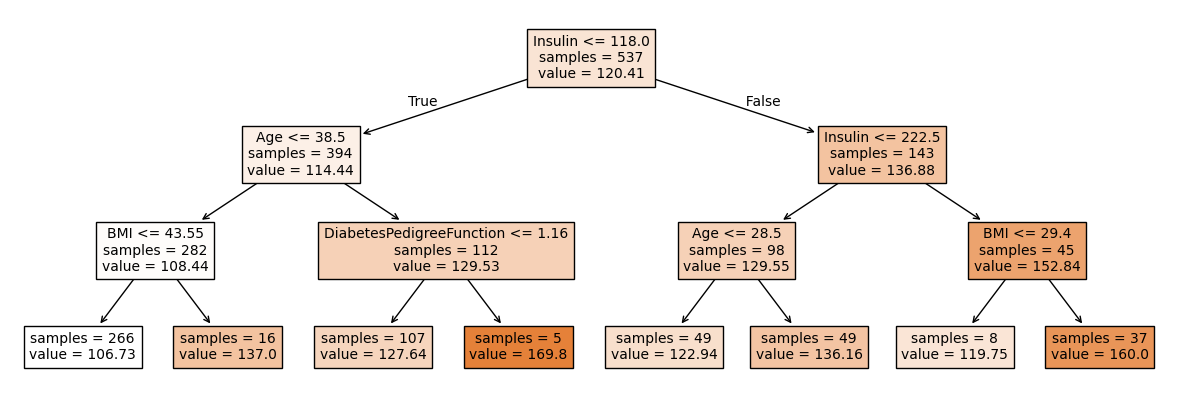

In [522]:
fig,ax=plt.subplots(figsize=(15,5))
plot=plot_tree(
    decision_tree=modelo_ar2,
    feature_names=pima.drop(columns="Glucose").columns,
    filled=True,
    impurity=False,
    fontsize=10,
    precision=2,
    ax=ax
)

In [523]:
#importancia de cada dato en el arbol

importancia_predictores2=pd.DataFrame(
    {
        "predictor":pima.drop(columns="Glucose").columns,
        "importancia":modelo_ar2.feature_importances_
    }

)

importancia_predictores2.sort_values(by="importancia", ascending=False)

,predictor,importancia
1,Insulin,0.488389
4,Age,0.280161
2,BMI,0.171873
3,DiabetesPedigreeFunction,0.059576
0,BloodPressure,0.000000


##Actividad, TITANIC y house_prices_large

In [524]:
#Bases de datos

titanic=pd.read_csv("/content/titanic-train .csv")

house=pd.read_csv("/content/housing .csv")
house.head()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [525]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [526]:
#dejar solo columnas utiles de titanic
titanic=titanic[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Embarked"]]
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [527]:
from sklearn.tree import DecisionTreeClassifier # Importar DecisionTreeClassifier

modelo_ar_titanic=DecisionTreeClassifier( random_state=2022, max_depth=5) # Cambiado a DecisionTreeClassifier
modelo_ar_house=DecisionTreeRegressor( random_state=2022, criterion = 'squared_error', max_depth=5)

### Calcular RMSE para los modelos Titanic y House Prices

In [528]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [529]:
#convertir y arreglar datos que sean String
#female=1 male=0
titanic["Sex"] = titanic["Sex"].replace({"male": 0, "female": 1})
titanic.head()

/tmp/ipython-input-1432251332.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic["Sex"] = titanic["Sex"].replace({"male": 0, "female": 1})


,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,0,22.0,1,0,S
1,1,1,1,38.0,1,0,C
2,1,3,1,26.0,0,0,S
3,1,1,1,35.0,1,0,S
4,0,3,0,35.0,0,0,S


In [530]:
print(titanic['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [531]:
titanic["Embarked"] = titanic["Embarked"].replace({"S": 0, "C": 1, "Q": 2})
titanic.head()

/tmp/ipython-input-75394533.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic["Embarked"] = titanic["Embarked"].replace({"S": 0, "C": 1, "Q": 2})


,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,0,22.0,1,0,0.0
1,1,1,1,38.0,1,0,1.0
2,1,3,1,26.0,0,0,0.0
3,1,1,1,35.0,1,0,0.0
4,0,3,0,35.0,0,0,0.0


In [532]:
house.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [533]:
#ahora arreglar el house

print(house['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [534]:
house["ocean_proximity"] = house["ocean_proximity"].replace({"<1H OCEAN": 0, "INLAND": 1, "NEAR OCEAN": 2, "NEAR BAY": 3, "ISLAND": 4})
house.head()

/tmp/ipython-input-1717297327.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  house["ocean_proximity"] = house["ocean_proximity"].replace({"<1H OCEAN": 0, "INLAND": 1, "NEAR OCEAN": 2, "NEAR BAY": 3, "ISLAND": 4})


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [535]:
x_Entrenotitanic, x_Validotitanic, y_Entrenotitanic, y_Validotitanic = train_test_split(titanic.drop(columns="Survived"), titanic["Survived"],train_size=.7,random_state=1279)
x_Entrenohouse, x_Validohouse, y_Entrenohouse, y_Validohouse = train_test_split(house.drop(columns="median_house_value"), house["median_house_value"],train_size=.7,random_state=1279)

In [536]:
# Entrenar el modelo de clasificación en los datos de entrenamiento de Titanic
modelo_ar_titanic.fit(x_Entrenotitanic, y_Entrenotitanic)

print("Modelo Titanic (clasificación) entrenado exitosamente.")

Modelo Titanic (clasificación) entrenado exitosamente.


In [537]:
modelo_ar_house.fit(x_Entrenohouse, y_Entrenohouse)

DecisionTreeRegressor(max_depth=5, random_state=2022)

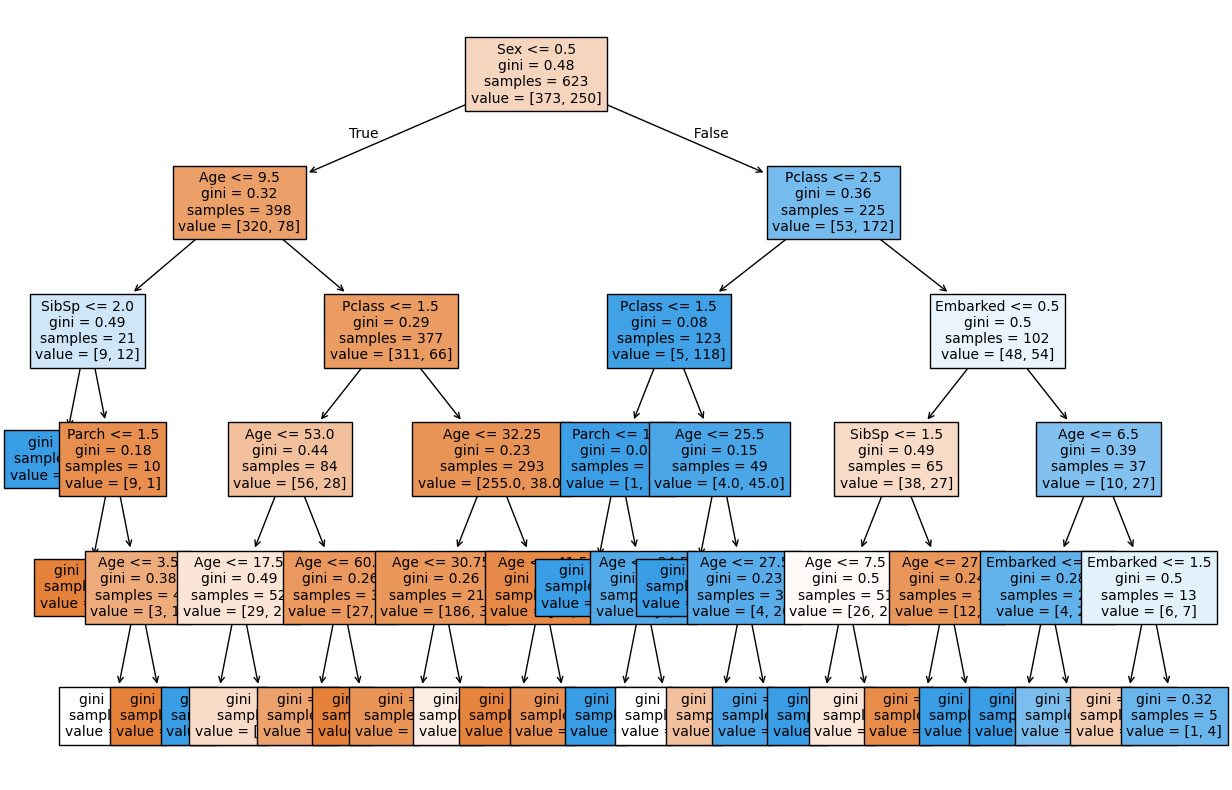

In [545]:
fig,ax=plt.subplots(figsize=(15,10)) #arbol titanic
plot=plot_tree(
    decision_tree=modelo_ar_titanic,
    feature_names=titanic.drop(columns="Survived").columns,
    filled=True,
    impurity=True, # Cambiado a True para mostrar Gini
    fontsize=10,
    precision=2,
    ax=ax
)

In [539]:
#importancia de cada dato en el arbol

importancia_predictores_titanic=pd.DataFrame(
    {
        "predictor":titanic.drop(columns="Survived").columns,
        "importancia":modelo_ar_titanic.feature_importances_
    }

)

importancia_predictores_titanic.sort_values(by="importancia", ascending=False)

,predictor,importancia
1,Sex,0.576316
0,Pclass,0.163170
2,Age,0.148419
3,SibSp,0.069085
5,Embarked,0.039938
4,Parch,0.003072


##El gini sale en el mismo arbol

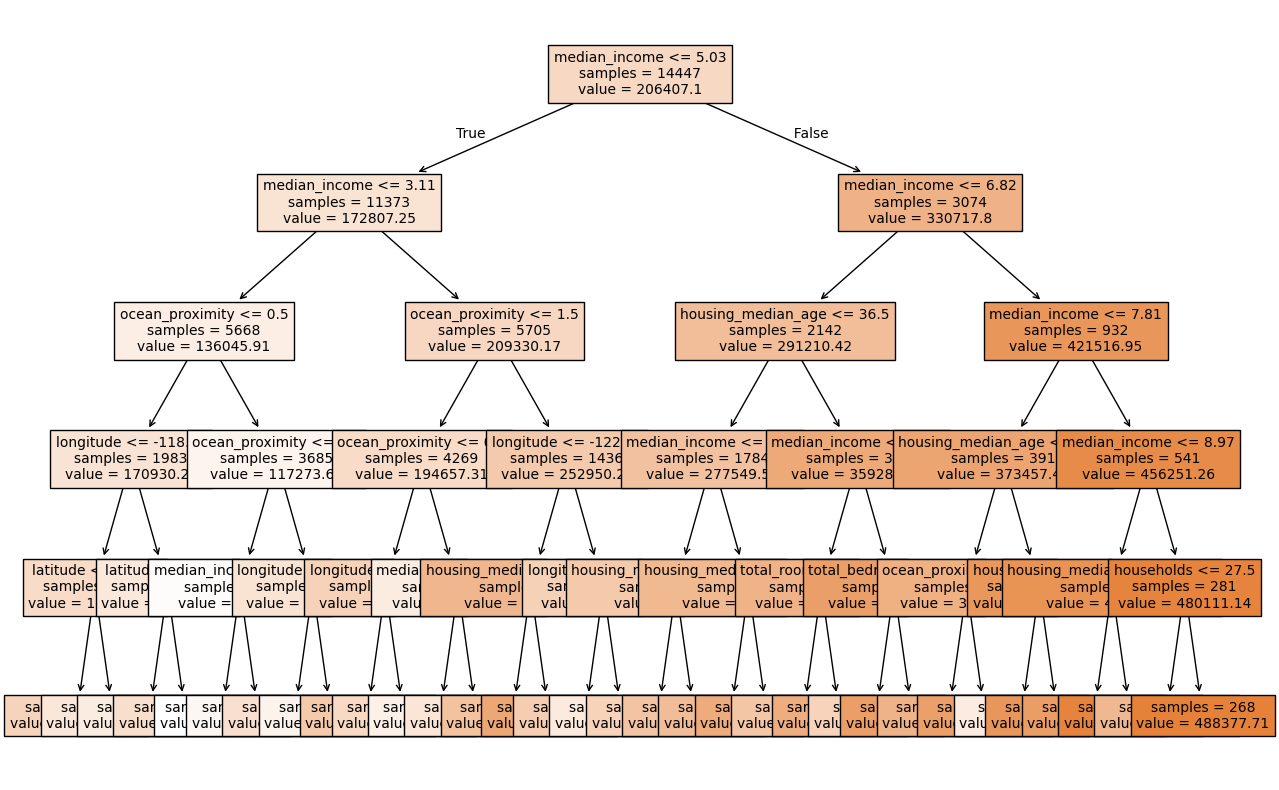

In [541]:
fig,ax=plt.subplots(figsize=(15,10)) #arbol house
plot=plot_tree(
    decision_tree=modelo_ar_house,
    feature_names=house.drop(columns="median_house_value").columns,
    filled=True,
    impurity=False,
    fontsize=10,
    precision=2,
    ax=ax
)

In [542]:
#importancia de cada dato en el arbol

importancia_predictores_house=pd.DataFrame(
    {
        "predictor":house.drop(columns="median_house_value").columns,
        "importancia":modelo_ar_house.feature_importances_
    }

)

importancia_predictores_house.sort_values(by="importancia", ascending=False)

,predictor,importancia
7,median_income,0.739760
8,ocean_proximity,0.156235
0,longitude,0.049189
2,housing_median_age,0.038949
1,latitude,0.008753
6,households,0.004428
3,total_rooms,0.001740
4,total_bedrooms,0.000946
5,population,0.000000


In [543]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predecir en los datos de validación para el modelo Titanic
y_pred_titanic = modelo_ar_titanic.predict(x_Validotitanic)

# Calcular el MSE y luego el RMSE para el modelo Titanic
mse_titanic = mean_squared_error(y_Validotitanic, y_pred_titanic)
rmse_titanic = np.sqrt(mse_titanic)

print(f"RMSE para el modelo Titanic: {rmse_titanic:.2f}")

# Predecir en los datos de validación para el modelo House Prices
y_pred_house = modelo_ar_house.predict(x_Validohouse)

# Calcular el MSE y luego el RMSE para el modelo House Prices
mse_house = mean_squared_error(y_Validohouse, y_pred_house)
rmse_house = np.sqrt(mse_house)

print(f"RMSE para el modelo House Prices: {rmse_house:.2f}")

RMSE para el modelo Titanic: 0.42
RMSE para el modelo House Prices: 70870.82
